# **PIPELINE WOE — DISCRETIZACIÓN MONÓTONA AUTOMÁTICA Y GENERACIÓN DE SQL**

Dado un `df` con `cuil_cuit`, `target` y N variables candidatas, este pipeline:

1. **Busca solo** una discretización con relación **monótona** contra el target.
2. **Descarta** las variables que no logran monotonicidad, o cuyo IV es débil o no significativo.
3. Calcula el **WOE** de las que sobreviven.
4. Emite **dos queries de BigQuery**: una de discretización y otra de asignación de WOE.

Toda la lógica vive en [`pipeline_woe.py`](pipeline_woe.py); este notebook solo lo maneja.

> **Convención de signo.** El WOE de este pipeline es `ln(P(malo)/P(bueno))` centrado:
> **WOE positivo = MÁS riesgo**. Es el signo **opuesto** al de
> [`woe_example/utils.py`](../woe_example/utils.py), que usa `ln(%buenos/%malos)`.
> Los valores no son comparables contra tus tablas bivariadas históricas sin invertir el signo.
> El IV va en escala de proporciones (umbrales 0.02 / 0.1 / 0.3 / 0.5), no en la escala ×100 de `utils.py`.

---
## **0. INSTALACIÓN**

`%pip` (no `!pip`) instala en el intérprete del kernel seleccionado. `duckdb` se usa solo en
la sección 6, para ejecutar el SQL generado y verificar que coincide con el resultado de pandas.

In [1]:
%pip install "fastwoe[plotting]" duckdb

# Si el proxy corporativo rompe la verificación SSL (SSLCertVerificationError), usá:
# %pip install --trusted-host pypi.org --trusted-host files.pythonhosted.org "fastwoe[plotting]" duckdb

   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ------------------- -------------------- 6.6/13.2 MB 36.6 MB/s eta 0:00:01
   ---------------------------------------  13.1/13.2 MB 35.7 MB/s eta 0:00:01
   ---------------------------------------- 13.2/13.2 MB 25.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys, os, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

# El módulo vive junto a este notebook.
sys.path.insert(0, os.path.abspath("."))
import pipeline_woe as pw

print("Kernel :", sys.executable)
import fastwoe, sklearn
print("fastwoe:", fastwoe.__version__, "| sklearn:", sklearn.__version__)
print("API    :", pw.__all__)

Kernel : c:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe
fastwoe: 0.1.8 | sklearn: 1.7.2
API    : ['detectar_direccion', 'buscar_binning_monotono', 'ajustar_pipeline', 'resumen_seleccion', 'aplicar_pipeline', 'generar_sql_discretizacion', 'generar_sql_woe', 'guardar_spec', 'cargar_spec']


---
## **1. DATOS**

`credit-g` de OpenML (1.000 solicitudes, 20 variables) más una columna `cuil_cuit` sintética,
para calcar la forma del input real: **identificador + target + variables candidatas**.

Se agregan a propósito varias **variables basura** —constante, casi toda nula, ruido puro,
categórica de cardinalidad altísima— para ver que el pipeline las descarta solo.

In [3]:
from sklearn.datasets import fetch_openml

def cargar_datos(seed=42):
    rng = np.random.default_rng(seed)
    try:
        bunch = fetch_openml("credit-g", version=1, as_frame=True, parser="auto")
        df = bunch.frame.copy()
        df["target"] = (df.pop("class") == "bad").astype(int)
        origen = "OpenML credit-g"
    except Exception as e:
        print(f"[aviso] Sin acceso a OpenML ({type(e).__name__}). Uso datos sintéticos.\n")
        df, origen = _sintetico(rng), "sintético (fallback sin red)"

    # dtype 'category' rompe predict_ci() de fastwoe 0.1.8 -> pasar a str
    for c in df.select_dtypes(include=["category"]).columns:
        df[c] = df[c].astype(str)

    # Identificador tipo CUIL/CUIT, único
    df.insert(0, "cuil_cuit", [f"20{n:09d}" for n in rng.choice(10**9, len(df), replace=False)])
    return df, origen


def _sintetico(rng, n=1000):
    df = pd.DataFrame({
        "duration":      rng.integers(4, 72, n),
        "credit_amount": rng.lognormal(7.8, 0.6, n).round(),
        "age":           rng.integers(19, 76, n),
        "checking_status": rng.choice(["<0", "0<=X<200", ">=200", "no checking"], n),
        "purpose":       rng.choice(["radio/tv", "new car", "used car", "business", "education"], n),
        "housing":       rng.choice(["own", "rent", "for free"], n),
    })
    logit = (-1.2 + 0.030 * df["duration"] - 0.020 * (df["age"] - 35)
             + 0.00008 * df["credit_amount"] - 0.60 * (df["checking_status"] == "no checking"))
    df["target"] = rng.binomial(1, 1 / (1 + np.exp(-logit)))
    return df


df, ORIGEN = cargar_datos()

# --- variables basura, para ver el filtro en acción ---
rng = np.random.default_rng(7)
df["v_constante"]      = 7.0
df["v_ruido"]          = rng.normal(size=len(df))
df["v_casi_toda_nula"] = np.where(rng.random(len(df)) < 0.9, np.nan, rng.normal(size=len(df)))
df["cat_alta_card"]    = [f"c{i}" for i in rng.integers(0, 500, len(df))]

print(f"Origen : {ORIGEN}")
print(f"Shape  : {df.shape}")
print(f"Target : tasa de malos = {df['target'].mean():.2%}")
df.head()

Origen : OpenML credit-g
Shape  : (1000, 26)
Target : tasa de malos = 30.00%


,cuil_cuit,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target,v_constante,v_ruido,v_casi_toda_nula,cat_alta_card
0,20376376771,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,0,7.0,0.001230,NaN,c27
1,20486657973,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,1,7.0,0.298746,NaN,c359
2,20320696168,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,0,7.0,-0.274138,NaN,c417
3,20139752356,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,0,7.0,-0.890592,NaN,c20
4,20738231088,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,1,7.0,-0.454671,1.82917,c191


---
## **2. AJUSTE DEL PIPELINE**

Una sola llamada. Por cada variable candidata:

- **Numéricas** → se detecta la dirección de la relación con Spearman, se ajusta un árbol con
  `monotonic_cst` en esa dirección, y se prueban profundidades de mayor a menor (4 → 3 → 2)
  quedándose con la **más fina** que produce bins válidos.
- **Categóricas** → se pliega la cola rara en `otros`. **No se les exige monotonicidad**:
  una categórica no tiene orden natural.

Un bin es válido si tiene al menos `min_pct_bin` de la población (default 5 %).

In [4]:
spec = pw.ajustar_pipeline(
    df,
    target_col="target",
    id_col="cuil_cuit",
    iv_min=0.02,               # IV mínimo para conservar
    iv_max=0.50,               # por encima: se marca sospecha de leakage (no descarta)
    exigir_significancia=True, # descarta IV no distinguible de cero
    min_pct_bin=0.05,          # población mínima por bin
    max_depth_grid=(4, 3, 2),  # profundidades del árbol, de más fina a más gruesa
)

m = spec["meta"]
print(f"Candidatas  : {m['n_candidatas']}")
print(f"Conservadas : {m['n_conservadas']}")
print(f"Tasa base   : {m['tasa_base']:.4%}")
print(f"Convención  : {m['convencion_woe']}")

Candidatas  : 24
Conservadas : 13
Tasa base   : 30.0000%
Convención  : ln(P(malo)/P(bueno)) centrado — WOE positivo = MÁS riesgo


### La tabla de auditoría

`resumen_seleccion()` es el reemplazo del Excel de bivariados: una fila por variable candidata,
con la decisión y **el motivo**. Es lo que se revisa antes de aceptar el modelo.

In [5]:
resumen = pw.resumen_seleccion(spec)
resumen

,variable,tipo,decision,n_bins,direccion,pct_nulos,iv,iv_se,iv_ci_lower,iv_ci_upper,significancia,monotona,motivo
0,checking_status,categorica,conservada,4,NaN,0.0,0.659056,0.078051,0.513036,0.818989,Significant,None,4 categorías conservadas + 'otros' — OJO: IV 0...
1,credit_history,categorica,conservada,4,NaN,0.0,0.289235,0.053103,0.187750,0.395911,Significant,None,3 categorías conservadas + 'otros'
2,duration,numerica,conservada,7,1.0,0.0,0.281575,0.054758,0.181654,0.396300,Significant,True,monótona con 7 bins (max_depth=4)
3,savings_status,categorica,conservada,5,NaN,0.0,0.187938,0.042173,0.113351,0.278668,Significant,None,4 categorías conservadas + 'otros'
4,purpose,categorica,conservada,7,NaN,0.0,0.152047,0.037534,0.080944,0.228073,Significant,None,6 categorías conservadas + 'otros'
5,credit_amount,numerica,conservada,5,1.0,0.0,0.150481,0.037104,0.078010,0.223455,Significant,True,monótona con 5 bins (max_depth=4)
6,property_magnitude,categorica,conservada,4,NaN,0.0,0.111799,0.031393,0.051109,0.174168,Significant,None,4 categorías conservadas + 'otros'
7,age,numerica,conservada,4,-1.0,0.0,0.099897,0.028724,0.043884,0.156480,Significant,True,monótona con 4 bins (max_depth=4)
8,employment,categorica,conservada,5,NaN,0.0,0.085656,0.027550,0.032437,0.140431,Significant,None,5 categorías conservadas + 'otros'
9,housing,categorica,conservada,3,NaN,0.0,0.083800,0.025968,0.032397,0.134189,Significant,None,3 categorías conservadas + 'otros'


In [6]:
# Solo las descartadas, con el motivo — que es la parte interesante.
resumen.loc[resumen["decision"] == "descartada", ["variable", "tipo", "iv", "significancia", "motivo"]]

,variable,tipo,iv,significancia,motivo
13,other_parties,categorica,0.031128,Not Significant,IV no significativo
14,v_ruido,numerica,0.027750,Not Significant,IV no significativo
15,installment_commitment,categorica,0.025473,Not Significant,IV no significativo
16,existing_credits,categorica,0.010573,Not Significant,IV 0.0106 < 0.02; IV no significativo
17,job,categorica,0.009001,Not Significant,IV 0.0090 < 0.02; IV no significativo
18,own_telephone,categorica,0.006282,Not Significant,IV 0.0063 < 0.02; IV no significativo
19,residence_since,categorica,0.003371,Not Significant,IV 0.0034 < 0.02; IV no significativo
20,num_dependents,categorica,0.000023,Not Significant,IV 0.0000 < 0.02; IV no significativo
21,v_casi_toda_nula,numerica,NaN,desconocida,algún bin queda por debajo de 5% de la poblaci...
22,v_constante,categorica,NaN,desconocida,sin variabilidad (una sola categoría observada)


Las cuatro variables basura salen descartadas solas, cada una por su motivo:

| variable | motivo |
|---|---|
| `v_constante` | sin variabilidad |
| `v_casi_toda_nula` | ningún bin alcanza el 5 % de población |
| `v_ruido` | IV por debajo del mínimo y no significativo |
| `cat_alta_card` | ninguna categoría alcanza el mínimo de casos |

> **Sobre `umbral_categorica`.** Una numérica con menos de 10 valores únicos se trata como
> categórica, así que **no recibe la exigencia de monotonicidad**. Si es una ordinal cuyo orden
> importa —una cuota de 1 a 4, un tramo de antigüedad— pasala por `forzar_numericas` para
> mandarla al árbol monótono:
>
> ```python
> spec = pw.ajustar_pipeline(df, forzar_numericas=["installment_commitment", "residence_since"])
> ```

---
## **3. INSPECCIÓN VARIABLE POR VARIABLE**

Los bins de una variable conservada. El WOE tiene que ser monótono a lo largo de `bin_01`, `bin_02`, …

In [7]:
conservadas = list(spec["variables"].keys())
numericas = [v for v in conservadas if spec["variables"][v]["tipo"] == "numerica"]
print("Conservadas:", conservadas)

VAR = numericas[0]
cfg = spec["variables"][VAR]

print(f"\n{VAR}  |  dirección {cfg['direccion']:+d}  |  IV {cfg['iv']:.4f}  |  max_depth {cfg['max_depth']}")
print(f"cortes: {cfg['cortes']}\n")
pd.DataFrame(cfg["bins"])

Conservadas: ['duration', 'credit_amount', 'age', 'checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'property_magnitude', 'other_payment_plans', 'housing', 'foreign_worker']

duration  |  dirección +1  |  IV 0.2816  |  max_depth 4
cortes: [8.5, 11.5, 15.5, 26.5, 34.5, 43.5]



,label,woe,iv,n,event_rate
0,bin_01,-1.244690,0.106443,94,0.106383
1,bin_02,-0.538440,0.022147,86,0.197674
2,bin_03,-0.268536,0.017035,251,0.247012
3,bin_04,0.092031,0.002919,340,0.320588
4,bin_05,0.184810,0.002106,59,0.338983
5,bin_06,0.521164,0.029642,100,0.420000
6,bin_07,1.124262,0.101283,70,0.571429


In [8]:
# Verificación explícita de la monotonicidad de todas las numéricas conservadas.
for v in numericas:
    bins = sorted(spec["variables"][v]["bins"], key=lambda b: b["label"])
    woes = [b["woe"] for b in bins if b["label"] != pw.BIN_NULO]
    d = np.diff(woes)
    sentido = "creciente" if (d >= -1e-9).all() else ("decreciente" if (d <= 1e-9).all() else "NO MONÓTONA")
    print(f"{v:<18} {len(woes)} bins  ->  WOE {sentido}")

duration           7 bins  ->  WOE creciente
credit_amount      5 bins  ->  WOE creciente
age                4 bins  ->  WOE decreciente


In [9]:
# Una categórica: qué valores quedaron en cada bin y cuáles cayeron en 'otros'.
categoricas = [v for v in conservadas if spec["variables"][v]["tipo"] == "categorica"]
VAR_CAT = categoricas[0]

print(f"{VAR_CAT}  |  IV {spec['variables'][VAR_CAT]['iv']:.4f}")
print("grupos:", spec["variables"][VAR_CAT]["grupos"], "\n")
pd.DataFrame(spec["variables"][VAR_CAT]["bins"])

checking_status  |  IV 0.6591
grupos: {'cat_01': ['0<=X<200'], 'cat_02': ['<0'], 'cat_03': ['>=200'], 'cat_04': ['no checking']} 



,label,woe,iv,n,event_rate
0,cat_01,0.399307,0.045923,269,0.390335
1,cat_02,0.814413,0.203569,274,0.492701
2,cat_03,-0.384318,0.008647,63,0.222222
3,cat_04,-1.170680,0.400917,394,0.116751


---
## **4. QUERY 1 — DISCRETIZACIÓN**

Un `CASE` por variable, con los cortes como constantes. Detalles que importan:

- La rama **`IS NULL` va primero**: en SQL `NULL <= 7.5` evalúa a `NULL`, no a `FALSE`, así que
  sin esa rama los nulos caerían silenciosamente en el `ELSE`.
- Los `WHEN` van en **orden ascendente** de corte y se apoyan en que el primer match gana.
- Los cortes se emiten con **precisión completa**: redondearlos movería casos de bin.
- Las etiquetas son `bin_01`, `bin_02`, … **cero-padded**, para que ordenen bien como string.

In [10]:
TABLA_ORIGEN = "mi-proyecto.mi_dataset.solicitudes"   # proyecto.dataset.tabla

sql_bins = pw.generar_sql_discretizacion(spec, TABLA_ORIGEN)
print(sql_bins)

-- Paso 1 — discretización de variables
-- Generado por pipeline_woe el 2026-07-28 20:07:32
-- Desarrollo: 1,000 filas | tasa base: 30.0000%
-- Convención WOE: ln(P(malo)/P(bueno)) centrado — WOE positivo = MÁS riesgo
-- Variables conservadas: 13 de 24 candidatas
-- Descartadas: v_ruido, v_casi_toda_nula, installment_commitment, other_parties, residence_since, existing_credits, job, num_dependents, own_telephone, v_constante, cat_alta_card
SELECT
  `cuil_cuit`,
  `target`,
  CASE
    WHEN `duration` IS NULL THEN 'nulo'
    WHEN `duration` <= 8.5 THEN 'bin_01'
    WHEN `duration` <= 11.5 THEN 'bin_02'
    WHEN `duration` <= 15.5 THEN 'bin_03'
    WHEN `duration` <= 26.5 THEN 'bin_04'
    WHEN `duration` <= 34.5 THEN 'bin_05'
    WHEN `duration` <= 43.5 THEN 'bin_06'
    ELSE 'bin_07'
  END AS `duration_bin`,
  CASE
    WHEN `credit_amount` IS NULL THEN 'nulo'
    WHEN `credit_amount` <= 708.5 THEN 'bin_01'
    WHEN `credit_amount` <= 3913.5 THEN 'bin_02'
    WHEN `credit_amount` <= 6193

---
## **5. QUERY 2 — ASIGNACIÓN DE WOE**

Monta la query anterior como CTE y mapea etiqueta de bin → valor de WOE.
Con `incluir_score=True` agrega `score_woe`, la suma de todos los WOE: el score aditivo
en log-odds del capítulo 1.

In [11]:
sql_woe = pw.generar_sql_woe(
    spec, TABLA_ORIGEN,
    incluir_bins=True,    # deja también las columnas _bin en la salida
    incluir_score=True,   # agrega score_woe
)
print(sql_woe)

-- Paso 2 — asignación de WOE
-- Generado por pipeline_woe el 2026-07-28 20:07:32
-- Desarrollo: 1,000 filas | tasa base: 30.0000%
-- Convención WOE: ln(P(malo)/P(bueno)) centrado — WOE positivo = MÁS riesgo
-- Variables conservadas: 13 de 24 candidatas
-- Descartadas: v_ruido, v_casi_toda_nula, installment_commitment, other_parties, residence_since, existing_credits, job, num_dependents, own_telephone, v_constante, cat_alta_card
WITH discretizado AS (
  SELECT
    `cuil_cuit`,
    `target`,
    CASE
      WHEN `duration` IS NULL THEN 'nulo'
      WHEN `duration` <= 8.5 THEN 'bin_01'
      WHEN `duration` <= 11.5 THEN 'bin_02'
      WHEN `duration` <= 15.5 THEN 'bin_03'
      WHEN `duration` <= 26.5 THEN 'bin_04'
      WHEN `duration` <= 34.5 THEN 'bin_05'
      WHEN `duration` <= 43.5 THEN 'bin_06'
      ELSE 'bin_07'
    END AS `duration_bin`,
    CASE
      WHEN `credit_amount` IS NULL THEN 'nulo'
      WHEN `credit_amount` <= 708.5 THEN 'bin_01'
      WHEN `credit_amount` <= 3913.5

> **Qué hacer con `score_woe`.** Es un score en log-odds, ya ordenado por riesgo, y sirve como
> baseline inmediato. Para convertirlo en probabilidad hay que sumarle el log-odds base y pasar
> por la sigmoide — pero lo correcto es **ajustar una regresión logística sobre las columnas
> `_woe`** y dejar que estime un coeficiente por variable (sección 7).

---
## **6. VALIDACIÓN: ¿EL SQL HACE LO MISMO QUE PYTHON?**

Esta es la sección que justifica todo el diseño. Se ejecuta el SQL generado sobre el mismo
DataFrame con **DuckDB** y se compara contra `aplicar_pipeline`. Tiene que dar **0 discrepancias**.

DuckDB no acepta los backticks de BigQuery, así que se reemplazan por comillas dobles. El
`CASE WHEN` —que es lo que se está validando— es idéntico en los dos dialectos.

> Esto **no sustituye** correr la query real en BigQuery, pero descarta el riesgo principal:
> que el `CASE WHEN` emitido no reproduzca el binning de Python.

In [12]:
import duckdb

def a_duckdb(sql, tabla_py="datos"):
    '''Adapta el SQL de BigQuery para poder ejecutarlo con DuckDB sobre un DataFrame.'''
    sin_comentarios = [l for l in sql.splitlines() if not l.lstrip().startswith("--")]
    return ("\n".join(sin_comentarios)
            .replace(f"`{TABLA_ORIGEN}`", tabla_py)
            .replace("`", '"'))

datos = df                      # DuckDB resuelve el nombre contra el DataFrame local
via_sql = duckdb.sql(a_duckdb(sql_woe)).df()
via_pandas = pw.aplicar_pipeline(df, spec)

print(f"SQL    : {via_sql.shape}")
print(f"pandas : {via_pandas.shape}")
via_sql.head()

SQL    : (1000, 29)
pandas : (1000, 52)


,cuil_cuit,target,duration_bin,credit_amount_bin,age_bin,checking_status_bin,credit_history_bin,purpose_bin,savings_status_bin,employment_bin,personal_status_bin,property_magnitude_bin,other_payment_plans_bin,housing_bin,foreign_worker_bin,duration_woe,credit_amount_woe,age_woe,checking_status_woe,credit_history_woe,purpose_woe,savings_status_woe,employment_woe,personal_status_woe,property_magnitude_woe,other_payment_plans_woe,housing_woe,foreign_worker_woe,score_woe
0,20376376771,0,bin_01,bin_02,bin_04,cat_02,cat_01,cat_05,cat_04,cat_04,cat_04,cat_04,cat_02,cat_02,cat_01,-1.244690,-0.219715,-0.311838,0.814413,-0.729637,-0.410933,-0.696781,-0.235160,-0.167163,-0.458777,-0.122643,-0.195267,0.033905,-3.944286
1,20486657973,1,bin_07,bin_03,bin_01,cat_01,cat_03,cat_05,cat_03,cat_01,cat_01,cat_04,cat_02,cat_02,cat_01,1.124262,0.340768,0.526748,0.399307,0.086097,-0.410933,0.267631,0.030040,0.233642,-0.458777,-0.122643,-0.195267,0.033905,1.854780
2,20320696168,0,bin_03,bin_02,bin_04,cat_04,cat_01,cat_02,cat_03,cat_02,cat_04,cat_04,cat_02,cat_02,cat_01,-0.268536,-0.219715,-0.311838,-1.170680,-0.729637,0.604297,0.267631,-0.390107,-0.167163,-0.458777,-0.122643,-0.195267,0.033905,-3.128529
3,20139752356,0,bin_06,bin_05,bin_04,cat_02,cat_03,cat_03,cat_03,cat_02,cat_04,cat_02,cat_02,cat_01,cat_01,0.521164,1.027298,-0.311838,0.814413,0.086097,0.093472,0.267631,-0.390107,-0.167163,0.028699,-0.122643,0.473275,0.033905,2.354204
4,20738231088,1,bin_04,bin_03,bin_04,cat_02,cat_02,cat_04,cat_03,cat_01,cat_04,cat_03,cat_02,cat_01,cat_01,0.092031,0.340768,-0.311838,0.814413,0.090767,0.354749,0.267631,0.030040,-0.167163,0.583995,-0.122643,0.473275,0.033905,2.479931


In [13]:
a = via_pandas.sort_values("cuil_cuit").reset_index(drop=True)
b = via_sql.sort_values("cuil_cuit").reset_index(drop=True)

filas = []
for v in conservadas:
    d_bin = int((a[f"{v}_bin"].astype(str) != b[f"{v}_bin"].astype(str)).sum())
    d_woe = int((~np.isclose(a[f"{v}_woe"].astype(float), b[f"{v}_woe"].astype(float),
                             rtol=0, atol=1e-12)).sum())
    filas.append({"variable": v, "bins_distintos": d_bin, "woe_distintos": d_woe})

comparacion = pd.DataFrame(filas)
total = comparacion[["bins_distintos", "woe_distintos"]].to_numpy().sum()

display(comparacion)
print(f"\nTotal de discrepancias: {total}  sobre {len(conservadas)} variables x {len(df):,} filas")
print("OK: el SQL reproduce exactamente el binning y el WOE de Python." if total == 0
      else "ATENCIÓN: hay discrepancias, revisar el generador.")

,variable,bins_distintos,woe_distintos
0,duration,0,0
1,credit_amount,0,0
2,age,0,0
3,checking_status,0,0
4,credit_history,0,0
5,purpose,0,0
6,savings_status,0,0
7,employment,0,0
8,personal_status,0,0
9,property_magnitude,0,0



Total de discrepancias: 0  sobre 13 variables x 1,000 filas
OK: el SQL reproduce exactamente el binning y el WOE de Python.


In [14]:
# El score también tiene que coincidir.
score_pandas = a[[f"{v}_woe" for v in conservadas]].sum(axis=1)
print("score_woe coincide:", bool(np.isclose(score_pandas, b["score_woe"].astype(float), atol=1e-10).all()))

score_woe coincide: True


### Comportamiento con datos nuevos

Lo que pasa cuando llega una cosecha nueva con **nulos donde no había** y **categorías que
nunca se vieron en desarrollo**: los primeros caen en `nulo`, las segundas en `otros`, y ambos
tienen su propio WOE. No queda ningún `NaN`, que es lo que hoy sí pasaría con `aplicar_woe`.

In [15]:
nuevo = df.head(200).copy()
nuevo.loc[nuevo.index[:50], numericas[0]] = np.nan
nuevo.loc[nuevo.index[:50], categoricas[0]] = "CATEGORIA_INEDITA"

aplicado = pw.aplicar_pipeline(nuevo, spec)

print(f"Nulos nuevos en '{numericas[0]}'      -> bin '{aplicado[f'{numericas[0]}_bin'].iloc[0]}'")
print(f"Categoría inédita en '{categoricas[0]}' -> bin '{aplicado[f'{categoricas[0]}_bin'].iloc[0]}'")
print(f"\n¿Quedó algún NaN en las columnas _woe? "
      f"{aplicado[[f'{v}_woe' for v in conservadas]].isna().any().any()}")

# Y el SQL hace exactamente lo mismo sobre esos datos.
datos = nuevo
sql_nuevo = duckdb.sql(a_duckdb(sql_woe)).df().sort_values("cuil_cuit").reset_index(drop=True)
esp_nuevo = aplicado.sort_values("cuil_cuit").reset_index(drop=True)
disc = sum(int((esp_nuevo[f"{v}_bin"].astype(str) != sql_nuevo[f"{v}_bin"].astype(str)).sum())
           for v in conservadas)
print(f"Discrepancias pandas vs SQL con datos nuevos: {disc}")

Nulos nuevos en 'duration'      -> bin 'nulo'
Categoría inédita en 'checking_status' -> bin 'otros'

¿Quedó algún NaN en las columnas _woe? False
Discrepancias pandas vs SQL con datos nuevos: 0


---
## **7. BASELINE: LOGÍSTICA SOBRE LAS COLUMNAS `_woe`**

El paso que hoy falta en `woe_example`: una vez que tenés las columnas WOE, ajustar la logística.
Los coeficientes deberían dar **cerca de 1** si el WOE está bien construido — es el *sanity check*
del capítulo 2.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

cols_woe = [f"{v}_woe" for v in conservadas]
X = via_pandas[cols_woe]
y = via_pandas["target"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

lr = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
auc = roc_auc_score(y_te, lr.predict_proba(X_te)[:, 1])

print(f"AUC test  = {auc:.4f}")
print(f"Gini test = {2 * auc - 1:.4f}")
print(f"Intercepto = {lr.intercept_[0]:+.4f}  (log-odds base ~ {np.log(y.mean() / (1 - y.mean())):+.4f})")

pd.DataFrame({"variable": cols_woe, "coef": lr.coef_[0]}).sort_values("coef", key=np.abs, ascending=False)

AUC test  = 0.8188
Gini test = 0.6376
Intercepto = -0.8575  (log-odds base ~ -0.8473)


,variable,coef
12,foreign_worker_woe,0.957096
10,other_payment_plans_woe,0.929105
6,savings_status_woe,0.846979
5,purpose_woe,0.785683
7,employment_woe,0.784966
0,duration_woe,0.760679
3,checking_status_woe,0.756389
8,personal_status_woe,0.741420
4,credit_history_woe,0.498011
11,housing_woe,0.493456


In [17]:
# El score aditivo crudo (sin logística) como referencia.
auc_score = roc_auc_score(via_pandas["target"], via_pandas[cols_woe].sum(axis=1))
print(f"score_woe crudo (suma sin pesos) -> AUC = {auc_score:.4f} | Gini = {2*auc_score-1:.4f}")
print(f"logística sobre las mismas columnas -> AUC = {auc:.4f} | Gini = {2*auc-1:.4f}")

score_woe crudo (suma sin pesos) -> AUC = 0.8209 | Gini = 0.6419
logística sobre las mismas columnas -> AUC = 0.8188 | Gini = 0.6376


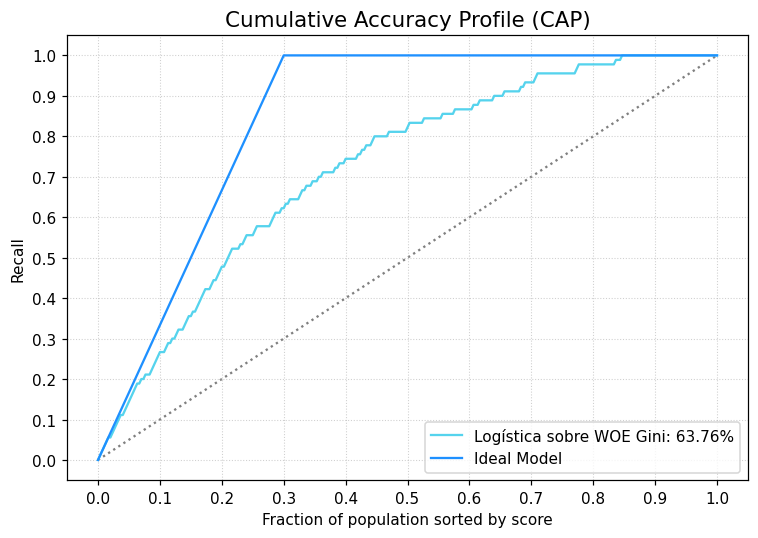

Gini = 0.6375661375661376


In [18]:
# Curva CAP con el Gini, usando el módulo de plots de FastWoe.
import matplotlib.pyplot as plt
from fastwoe import plot_performance

fig, ax, gini = plot_performance(
    y_te.values, lr.predict_proba(X_te)[:, 1],
    labels=["Logística sobre WOE"], figsize=(7, 5),
)
plt.show()
print(f"Gini = {gini}")

---
## **8. PERSISTIR EL MODELO**

El `spec` es el **artefacto versionable**: cortes, grupos, WOE por bin y metadatos. Guardándolo
en JSON podés re-emitir el SQL en cualquier momento **sin re-entrenar**, que es lo que se necesita
para reproducir un scorecard puesto en producción hace seis meses.

In [19]:
RUTA_SPEC = "spec_modelo.json"

pw.guardar_spec(spec, RUTA_SPEC)
spec_recargado = pw.cargar_spec(RUTA_SPEC)

sql_recargado = pw.generar_sql_woe(spec_recargado, TABLA_ORIGEN, incluir_bins=True)
print("El SQL re-emitido desde el JSON es idéntico:", sql_recargado == sql_woe)
print(f"\nTamaño del spec: {os.path.getsize(RUTA_SPEC):,} bytes")
print(f"Variables      : {list(spec_recargado['variables'].keys())}")

El SQL re-emitido desde el JSON es idéntico: True

Tamaño del spec: 27,473 bytes
Variables      : ['duration', 'credit_amount', 'age', 'checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'property_magnitude', 'other_payment_plans', 'housing', 'foreign_worker']


---
## **9. CIERRE: CÓMO SE RELACIONA CON `woe_example/`**

| Paso del flujo actual | En este pipeline |
|---|---|
| Escribir a mano `config_bins` por variable | `ajustar_pipeline()` encuentra los cortes solo |
| Mirar la monotonicidad en el Excel de colores | `monotonic_cst` la **impone**; `resumen_seleccion()` la certifica |
| Ordenar por `iv_total_variable` | IV en escala de proporciones **con SE y significancia** |
| Decidir a ojo qué variable entra | criterio explícito y auditable en la columna `motivo` |
| Transcribir cortes y WOE al `CASE WHEN` a mano | `generar_sql_discretizacion()` / `generar_sql_woe()` |
| — | validación automática de que el SQL == Python |
| `calcular_woe_mapping` / `aplicar_woe` | `spec` + `aplicar_pipeline()`, sin `NaN` |

**Lo que este pipeline NO reemplaza** de [`discretizar_variables`](../woe_example/utils.py#L238):
el control declarativo de cortes con `nivel_cero`, `dicotomica` y `custom`. Si el negocio pide
que `x <= 0` sea su propio bucket, eso sigue siendo una decisión tuya que el árbol no va a
adivinar. La ruta híbrida —tu binning declarativo + esta capa de WOE y SQL— sigue siendo válida.

> **Recordatorio del signo.** Todo lo que sale de acá está en la convención
> `WOE positivo = más riesgo`, opuesta a la de `utils.py`. Está escrito en el comentario de
> cabecera de cada query generada.